# Understanding Support Vector Machines from First Principles
### Margin, Regularisation, Kernels and Support-Vector Composition in Practice

**Student:** Teddy Ryu (12108700)

This public notebook is the executable entry point for the complete project. The from-scratch implementations are maintained as modular Python files in the linked public GitHub repository and are loaded below so the same source is used by both the notebook and the reproducible command-line workflow.

## 1. Environment and source files

In [1]:
!pip -q install numpy scikit-learn matplotlib
!git clone -q https://github.com/TeddybearAi/svm-from-first-principles.git
%cd /content/svm-from-first-principles
print('Repository ready.')

/content/svm-from-first-principles
Repository ready.


The implementation is split into five auditable modules:

- `01_data.py`: data generation, real-data loading, splitting and standardisation
- `02_primal_svm.py`: primal soft-margin SVM from scratch
- `03_dual_smo.py`: simplified dual SMO SVM from scratch
- `04_experiments.py`: validation checks, Sweeps A–F and verification diagnostics
- `05_make_figures.py`: generation of Figures 1–5

In [2]:
from pathlib import Path
for fn in ['01_data.py','02_primal_svm.py','03_dual_smo.py','04_experiments.py','05_make_figures.py']:
    print(f'{fn}: {len(Path(fn).read_text().splitlines())} lines')

01_data.py: 100 lines
02_primal_svm.py: 153 lines
03_dual_smo.py: 214 lines
04_experiments.py: 401 lines
05_make_figures.py: 141 lines


## 2. Load the from-scratch implementations

In [3]:
import importlib.util
def load_module(name, path):
    spec = importlib.util.spec_from_file_location(name, path)
    mod = importlib.util.module_from_spec(spec)
    spec.loader.exec_module(mod)
    return mod

data01 = load_module('data01', '01_data.py')
primal02 = load_module('primal02', '02_primal_svm.py')
dual03 = load_module('dual03', '03_dual_smo.py')
exp04 = load_module('exp04', '04_experiments.py')
print('Loaded PrimalSVM and DualSVM_SMO from the public source files.')

Loaded PrimalSVM and DualSVM_SMO from the public source files.


## 3. Basic implementation checks

In [4]:
import numpy as np
from sklearn.svm import SVC

X, y = data01.make_synthetic(overlap='low')
(Xtr, ytr), (Xval, yval), (Xte, yte), _ = data01.split_and_scale(X, y)
m = primal02.PrimalSVM(C=1.0, lr=0.01, n_epochs=3000).fit(Xtr, ytr)
ref = SVC(kernel='linear', C=1.0).fit(Xtr, ytr)
print('Primal scratch test accuracy:', (m.predict(Xte) == yte).mean())
print('sklearn reference accuracy:', ref.score(Xte, yte))
primal02.verify_against_sklearn(m, ref, Xte, label='Synthetic low-overlap')

Primal scratch test accuracy: 0.95
sklearn reference accuracy: 0.95
  [Synthetic low-overlap] w cosine similarity=0.99999  b diff=0.00963  mean|Δscore|=0.02732  max|Δscore|=0.07789


## 4. C=100 geometry spot checks used in the report

In [5]:
c100_checks = exp04.primal_c100_spot_checks()
for r in c100_checks:
    print(f"{r['overlap']} overlap: scratch ||w||={r['scratch_w_norm']:.6f}, sklearn ||w||={r['sklearn_w_norm']:.6f}, cosine={r['cosine_similarity']:.9f}, test acc={r['scratch_test_acc']:.3f}/{r['sklearn_test_acc']:.3f}")

low overlap: scratch ||w||=5.729148, sklearn ||w||=5.804099, cosine=0.999999363, test acc=0.933/0.933
high overlap: scratch ||w||=1.426883, sklearn ||w||=1.427847, cosine=0.999998999, test acc=0.750/0.750


## 5. Full experimental sweeps

The next cell regenerates the full experiment set reported in the paper: validation of implementation settings, Sweeps A–F, KKT/tolerance diagnostics, the paired real-data comparison, and the failure-case analysis. The simplified SMO sweeps can take some time on Colab CPU.

In [6]:
!python 04_experiments.py

=== Settings validation (uses VALIDATION split only; test sets untouched here) ===
--- Validating primal lr_schedule choice (at C=100, the hardest case) ---
  lr_schedule=fixed      val_acc=0.750  loss tail_std=7695.862
  lr_schedule=c_scaled   val_acc=0.717  loss tail_std=0.839
  -> 'c_scaled' selected (lower tail_std = stabilised, not oscillating); used for ALL C-sweep runs.
--- Validating dual SMO max_passes choice ---
  max_passes=5   val_acc=0.717  n_SV=82
  max_passes=10  val_acc=0.717  n_SV=81
  max_passes=15  val_acc=0.717  n_SV=81
  max_passes=20  val_acc=0.717  n_SV=81
  -> Validation accuracy is unchanged from 5 passes onward; support-vector count stabilises by 10.
     max_passes=15 retained as a conservative buffer beyond the observed stabilisation point; used for ALL dual-SMO sweep runs.
--- Validating RBF gamma choice (on the moons regime, at reference C=1) ---
  gamma=0.1  val_acc=0.817
  gamma=0.5  val_acc=0.933
  gamma=1.0  val_acc=0.967
  gamma=2.0  val_acc=0.967
  g

## 6. Figures 1–5

Saved fig1_primal_C_sweep.png, fig2_dual_sv_counts.png, fig3_kernel_comparison_moons.png, fig4_real_dataset_C_sweep.png
Saved fig5_sv_composition.png


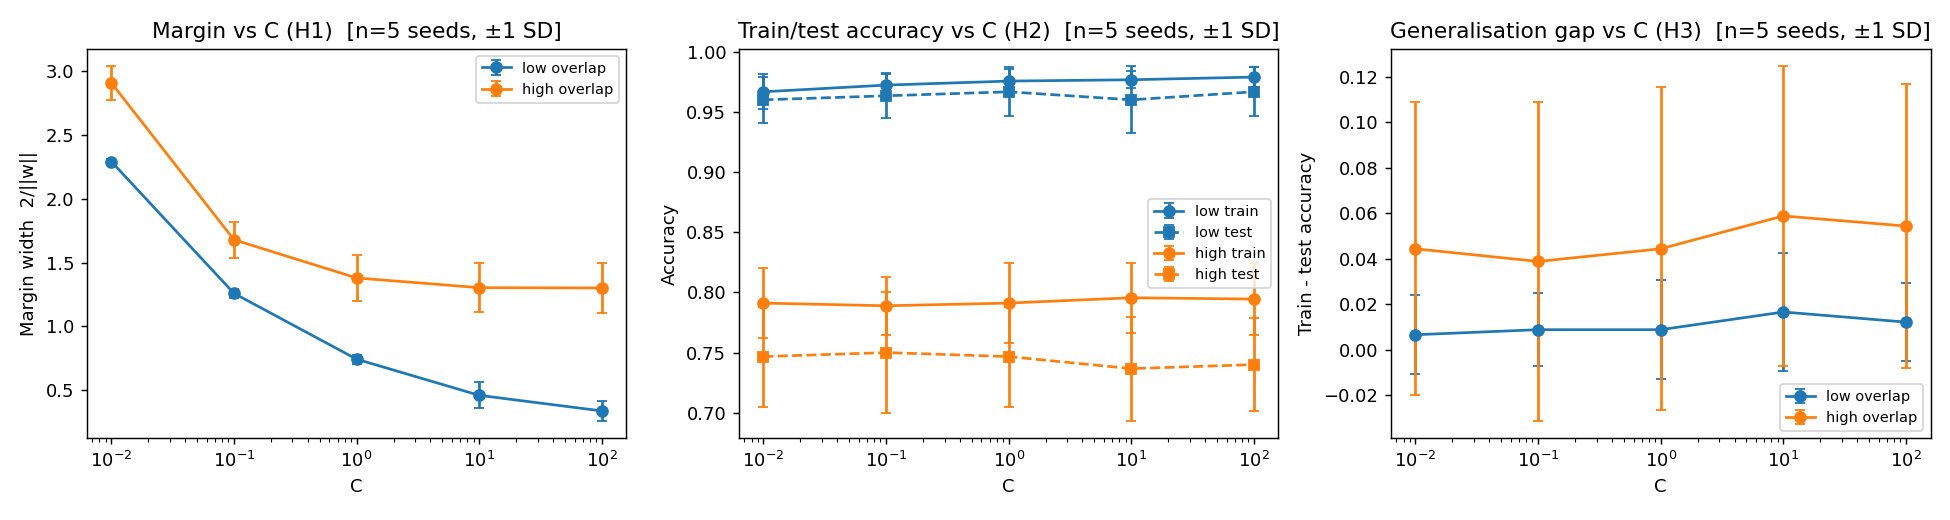

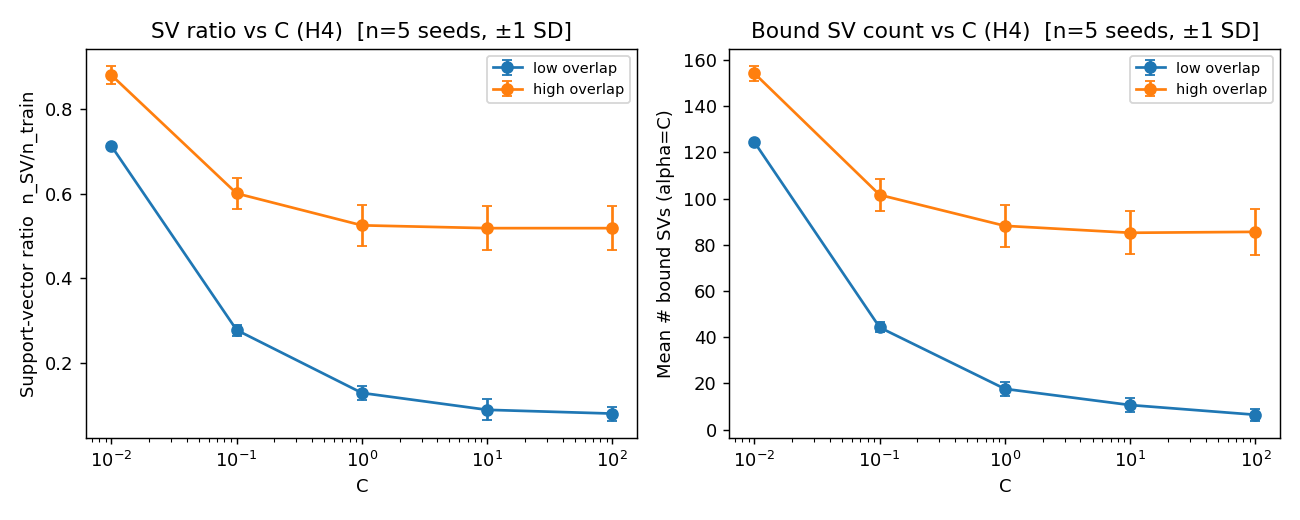

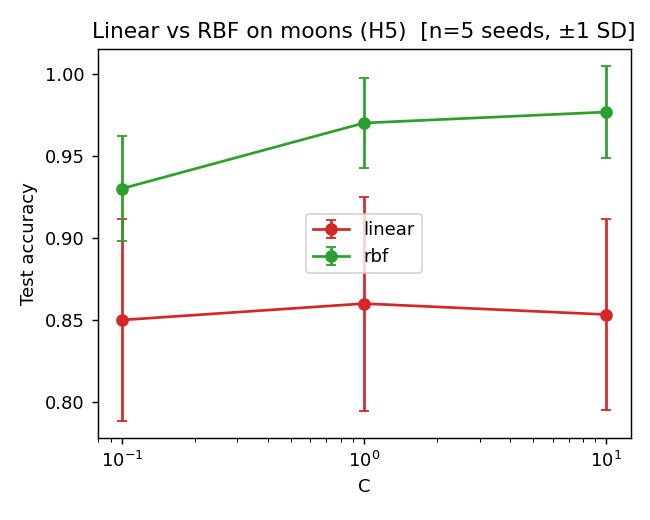

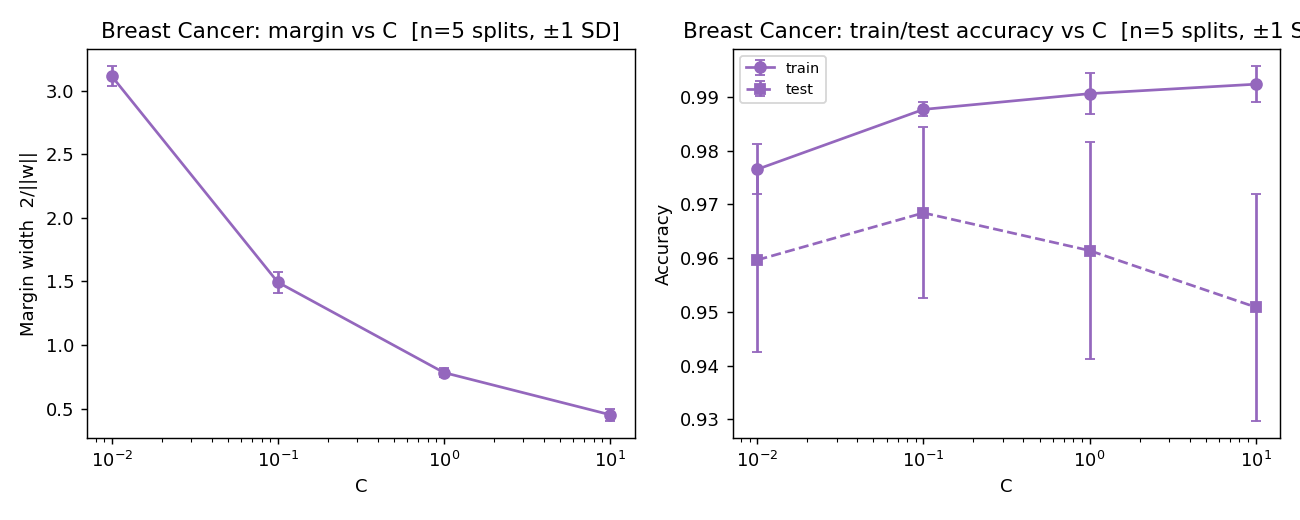

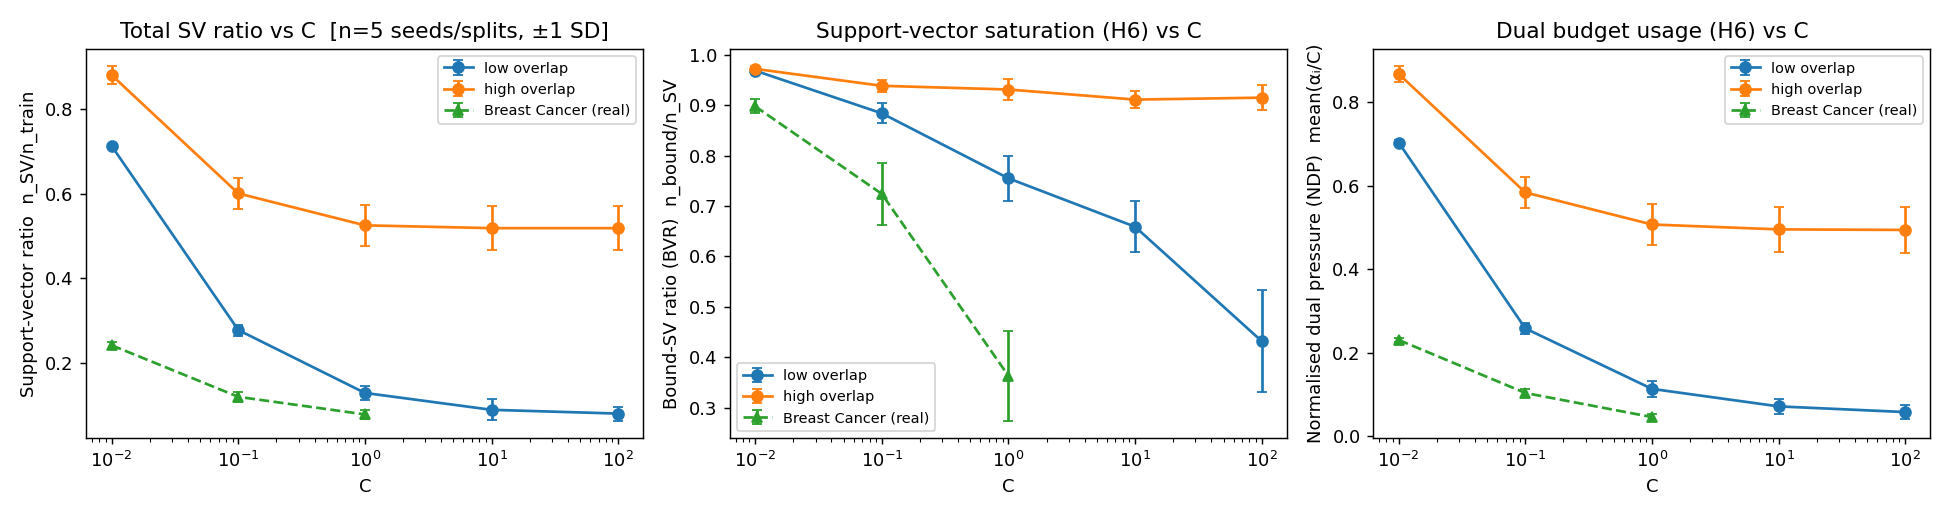

In [7]:
!python 05_make_figures.py
from IPython.display import display, Image
for fn in ['fig1_primal_C_sweep.png','fig2_dual_sv_counts.png','fig3_kernel_comparison_moons.png','fig4_real_dataset_C_sweep.png','fig5_sv_composition.png']:
    display(Image(filename=fn))

## 7. Raw results

The full numerical outputs used for the report tables are saved to `sweep_results.json`. The separate `c100_primal_verification.json` records the explicit C=100 scratch-vs-sklearn geometry checks.